In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

warnings.filterwarnings('ignore')

/usr/local/miniconda/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
print("--- Initial Exploratory Data Analysis ---")

# Read the data
df = pd.read_csv('salesdaily_w_stock.csv')

# Setting up parsing for Date column
df['datum'] = pd.to_datetime(df['datum'])
df.set_index('datum', inplace=True)
df.sort_index(inplace=True)

# Define the medicine groups
medicine_groups_arr = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

print('Total Number of Records: ',df.shape[0])
print('Total Number of Cols: ',df.shape[1])
print('Medicine Groups :', medicine_groups_arr)

print('First 10 rows of the dataset:')
display(df.head(10))

#  Mapping for your stock columns
sod_cols = [f"{med}_s_sod" for med in medicine_groups_arr]
eod_cols = [f"{med}_s_eod" for med in medicine_groups_arr]

--- Initial Exploratory Data Analysis ---
Total Number of Records:  2107
Total Number of Cols:  27
Medicine Groups : ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
First 10 rows of the dataset:


,Weekday,Year,Month,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,...,N02BE_s_sod,N02BE_s_eod,N05B_s_sod,N05B_s_eod,N05C_s_sod,N05C_s_eod,R03_s_sod,R03_s_eod,R06_s_sod,R06_s_eod
datum,,,,,,,,,,,,,,,,,,,,,
2014-01-01,Wednesday,2014,1,0.00,0.00,0.0,0.00,0.0,0.0,0.0,...,200.00,200.00,200.0,200.0,100.0,100.0,100.0,100.0,100.0,100.0
2014-01-02,Thursday,2014,1,0.00,3.67,3.4,32.40,7.0,0.0,0.0,...,200.00,167.60,200.0,193.0,100.0,100.0,100.0,100.0,100.0,98.0
2014-01-03,Friday,2014,1,8.00,4.00,4.4,50.60,16.0,0.0,20.0,...,167.60,117.00,193.0,177.0,100.0,100.0,100.0,80.0,98.0,94.0
2014-01-04,Saturday,2014,1,2.00,1.00,6.5,61.85,10.0,0.0,9.0,...,117.00,55.15,177.0,167.0,100.0,100.0,80.0,71.0,94.0,93.0
2014-01-05,Sunday,2014,1,4.00,3.00,7.0,41.10,8.0,0.0,3.0,...,394.15,353.05,167.0,159.0,100.0,100.0,71.0,68.0,93.0,93.0
2014-01-06,Monday,2014,1,5.00,1.00,4.5,21.70,16.0,2.0,6.0,...,353.05,331.35,159.0,143.0,100.0,98.0,68.0,62.0,93.0,91.0
2014-01-07,Tuesday,2014,1,0.00,0.00,0.0,0.00,0.0,0.0,0.0,...,331.35,331.35,143.0,143.0,98.0,98.0,62.0,62.0,91.0,91.0
2014-01-08,Wednesday,2014,1,5.33,3.00,10.5,26.40,19.0,1.0,10.0,...,331.35,304.95,143.0,124.0,98.0,97.0,62.0,52.0,91.0,91.0
2014-01-09,Thursday,2014,1,7.00,1.68,8.0,25.00,16.0,0.0,3.0,...,304.95,279.95,124.0,108.0,97.0,97.0,52.0,49.0,91.0,89.0


--- Initial Exploratory Data Analysis Part-2 ---
Avg Monthly Sales M01AB ::  147.06162615741667
Avg Monthly Sales M01AE ::  113.8926200810139
Avg Monthly Sales N02BA ::  113.44734722223612
Avg Monthly Sales N02BE ::  875.0750376158334
Avg Monthly Sales N05B ::  258.5241319440417
Avg Monthly Sales N05C ::  16.859375
Avg Monthly Sales R03 ::  160.73365162044445
Avg Monthly Sales R06 ::  84.65024305555556




Higest Sale Month for M01AB 
    Year  Month       M01AB
0  2014     11  138.080000
1  2015     10  195.810000
2  2016      8  211.130000
3  2017      1  181.902083
4  2018     11  172.290000
5  2019      7  181.000000




Monthly Sale for December for M01AB 
    Year   M01AB
0  2014  131.90
1  2015  159.46
2  2016  169.32
3  2017  160.01
4  2018  147.71






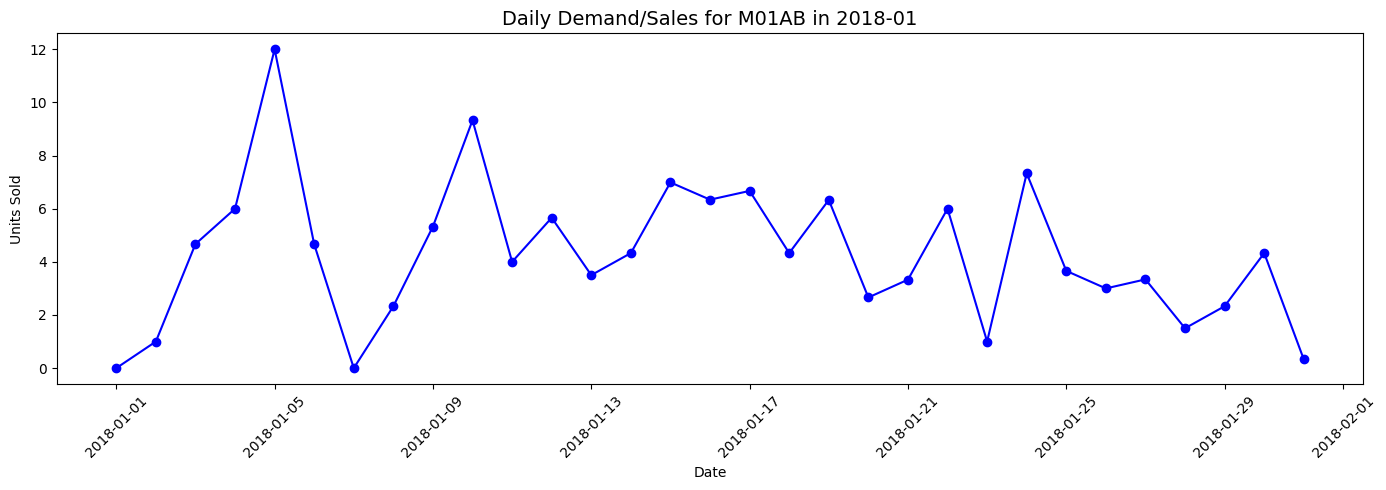

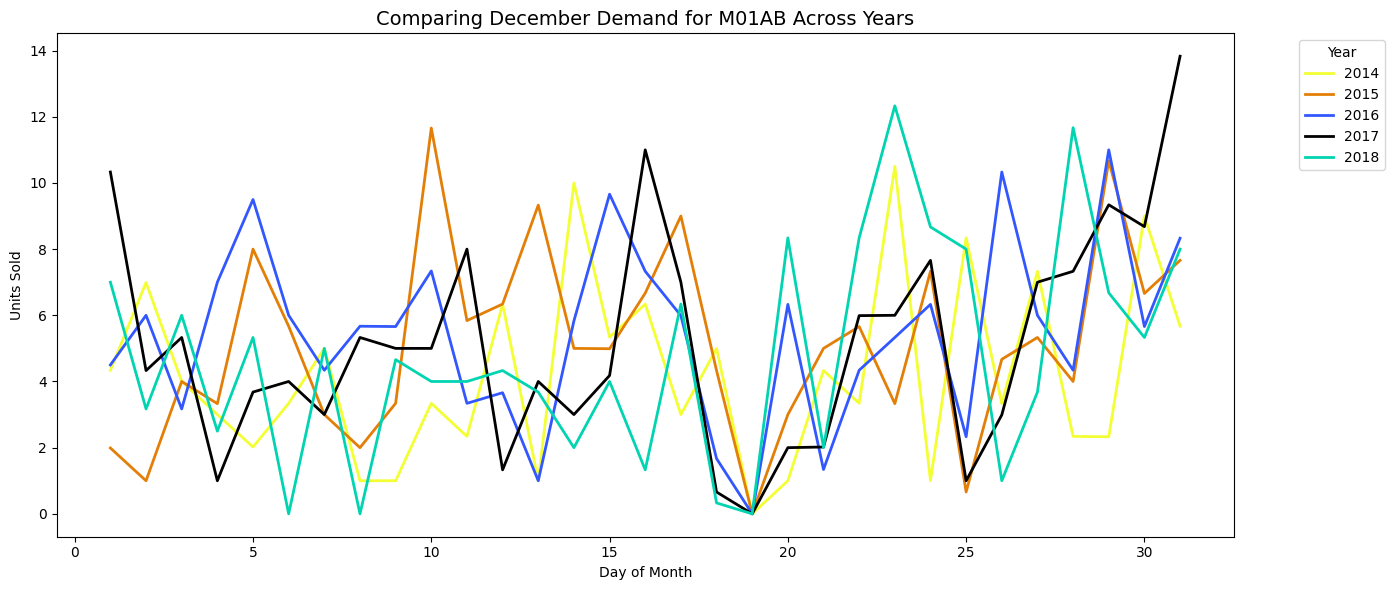

In [3]:
print("--- Initial Exploratory Data Analysis Part-2 ---")

for medicine_group in medicine_groups_arr:
    print(f"Avg Monthly Sales {medicine_group} :: ", df[medicine_group].sum()/72)

print('\n\n\n')

monthly_sales = df.groupby(['Year', 'Month'])['M01AB'].sum().reset_index()
highest_months = monthly_sales.loc[monthly_sales.groupby('Year')['M01AB'].idxmax()]
highest_months = highest_months.sort_values('Year').reset_index(drop=True)

print('Higest Sale Month for M01AB \n', highest_months)

print('\n\n\n')

target_month = df[df['Month'] == 12]
yearly_breakdown = target_month.groupby('Year')['M01AB'].sum().reset_index()
print('Monthly Sale for December for M01AB \n', yearly_breakdown)

print('\n\n\n')

# Let's looking at 'M01AB' over a specific month-year
target_med = 'M01AB'
target_year_month = '2018-01'

def show_demand_graph(target_med, target_year_month):
    plt.figure(figsize=(14, 5))
    plt.plot(df.loc[target_year_month, target_med], marker='o', color='b', linestyle='-')
    plt.title(f"Daily Demand/Sales for {target_med} in {target_year_month}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

show_demand_graph('M01AB', '2018-01')

# Demand across years for a specific month

df['Year'] = df.index.year
df['Month'] = df.index.month


target_month = 12  # December
dec_data = df[df['Month'] == target_month]

plt.figure(figsize=(14, 6))
dec_pivot = dec_data.pivot_table(index=dec_data.index.day, columns='Year', values=target_med)


custom_colors = ['#F3FF33', '#E37F07', '#3357FF', '#000000', '#00D4B1', '#EB15B9']

sns.lineplot(data=dec_pivot, dashes=False, palette=custom_colors, linewidth=2)  #palette='viridis',
plt.title(f"Comparing December Demand for {target_med} Across Years", fontsize=14)
plt.xlabel("Day of Month")
plt.ylabel("Units Sold")
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


--- Total Warehouse Stock Tracking ---


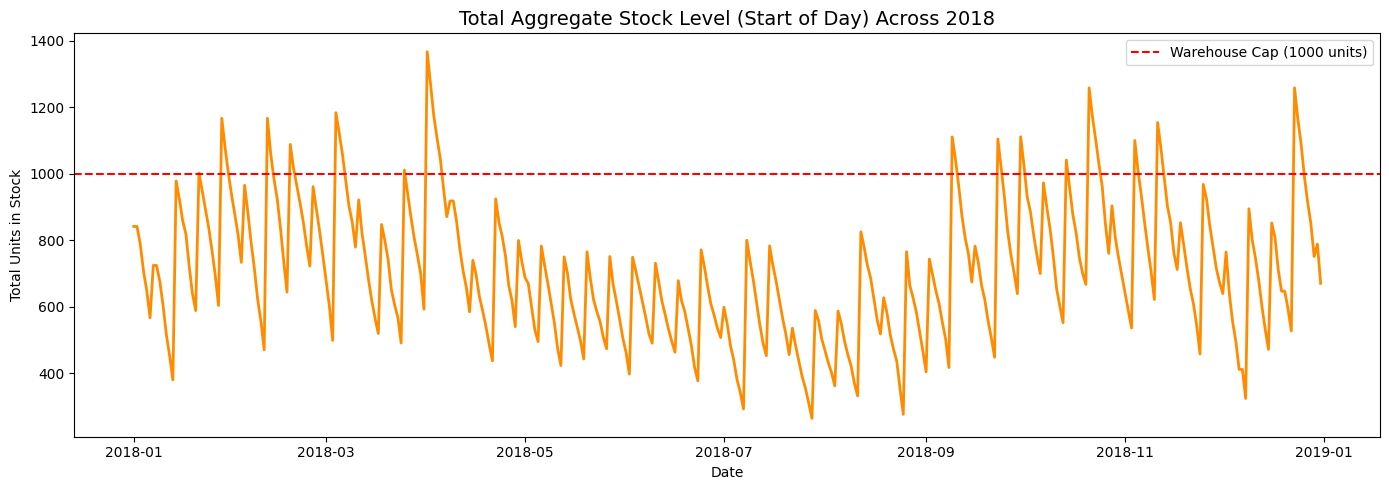

In [4]:
print("\n--- Total Warehouse Stock Tracking ---")

# Calculate total daily inventory across all medicine groups using Start of Day
df['Total_SOD_Stock'] = df[sod_cols].sum(axis=1)

target_year = 2018
year_stock = df[df['Year'] == target_year]

plt.figure(figsize=(14, 5))
plt.plot(year_stock.index, year_stock['Total_SOD_Stock'], color='darkorange', linewidth=2)
plt.axhline(y=1000, color='r', linestyle='--', label='Warehouse Cap (1000 units)')
plt.title(f"Total Aggregate Stock Level (Start of Day) Across 2018", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Units in Stock")
plt.legend()
plt.tight_layout()
plt.show()


--- Individual Stock Depletion ---


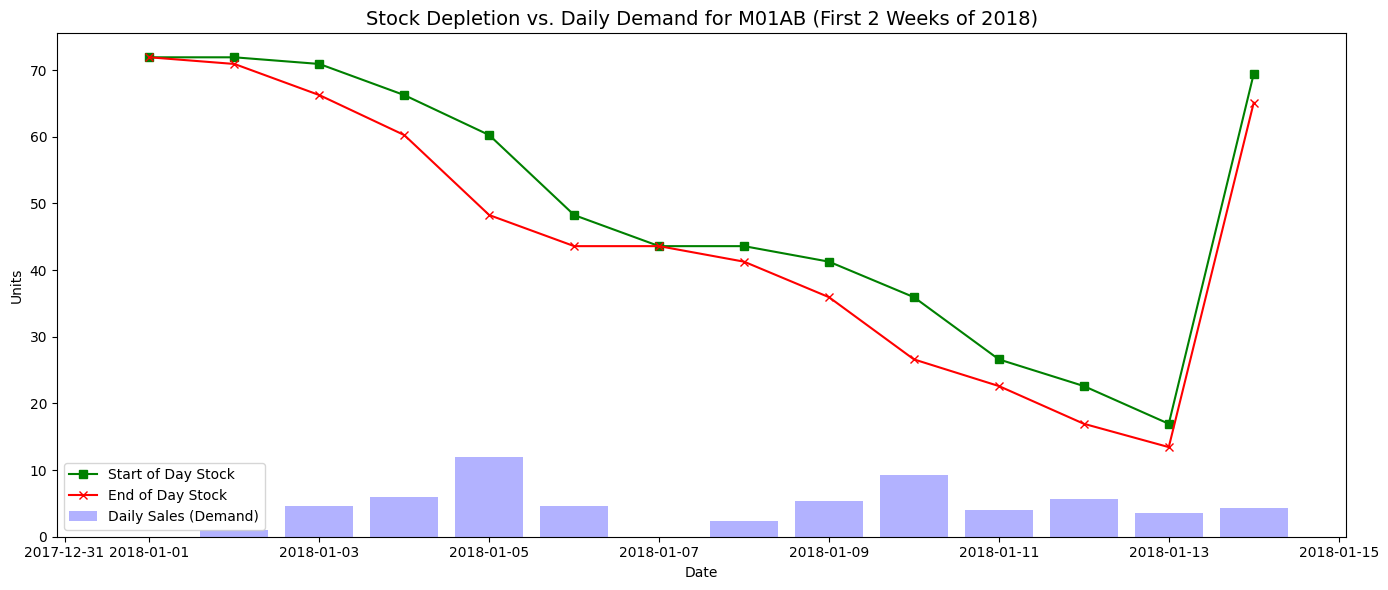

In [5]:
print("\n--- Individual Stock Depletion ---")

sample_window = df.loc['2018-01-01':'2018-01-14']

plt.figure(figsize=(14, 6))
plt.plot(sample_window.index, sample_window[f"{target_med}_s_sod"], label='Start of Day Stock', marker='s', color='green')
plt.plot(sample_window.index, sample_window[f"{target_med}_s_eod"], label='End of Day Stock', marker='x', color='red')
plt.bar(sample_window.index, sample_window[target_med], alpha=0.3, label='Daily Sales (Demand)', color='blue')

plt.title(f"Stock Depletion vs. Daily Demand for {target_med} (First 2 Weeks of 2018)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
split_date = '2019-01-01'

def create_lag_features(data, target_col):

    df_features = data[[target_col]].copy()
    df_features.columns = ['actual_demand']
    
    # Time-based features
    df_features['dayofweek'] = df_features.index.dayofweek
    df_features['month'] = df_features.index.month
    df_features['is_weekend'] = df_features['dayofweek'].isin([5, 6]).astype(int)
    
    # Lag features (Looking backward)
    df_features['lag_1'] = df_features['actual_demand'].shift(1)
    df_features['lag_2'] = df_features['actual_demand'].shift(2)
    df_features['lag_7'] = df_features['actual_demand'].shift(7) # Same day last week
    
    # Rolling window statistics
    df_features['rolling_mean_3'] = df_features['actual_demand'].shift(1).rolling(window=3).mean()
    df_features['rolling_mean_7'] = df_features['actual_demand'].shift(1).rolling(window=7).mean()
    
    return df_features.dropna()

print("--- Aligning Indices & Training LightGBM ---")

# Step 1A: Get the absolute common date index used by your ML test set
df_ml_sample = create_lag_features(df, medicine_groups_arr[0])
test_dates_index = df_ml_sample[df_ml_sample.index >= split_date].index

# Step 1B: Re-align actual test values to match this exact slice perfectly
actual_test_values_aligned = {}
for med in medicine_groups_arr:
    actual_test_values_aligned[med] = df.loc[test_dates_index, med].values

# Extract aligned historical comparison stock numbers
historical_test_stock_aligned = df.loc[test_dates_index, 'Total_SOD_Stock'].values

# Step 1C: Align baseline and SARIMA arrays to this exact slice
predictions_baseline_aligned = {}
predictions_sarima_aligned = {}
predictions_xgb_aligned = {}
predictions_lgb_aligned = {}

--- Aligning Indices & Training LightGBM ---


In [7]:
print("--- Starting Model Training and Forecasting ---")

# Re-compute or slice forecasts to perfectly match test_dates_index
for med in medicine_groups_arr:
    # Baseline slice
    df_base = df[[med]].copy()
    df_base['pred_baseline'] = df_base[med].shift(1).rolling(window=7).mean()
    predictions_baseline_aligned[med] = df_base.loc[test_dates_index, 'pred_baseline'].fillna(0).values
    
    # ML Feature Prep
    df_ml = create_lag_features(df, med)
    train_ml = df_ml[df_ml.index < split_date]
    test_ml = df_ml[df_ml.index >= split_date]
    
    X_cols = ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_7', 'rolling_mean_3', 'rolling_mean_7']
    X_train, y_train = train_ml[X_cols], train_ml['actual_demand']
    X_test = test_ml[X_cols]
    
    # Re-align XGBoost array values
    model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    model_xgb.fit(X_train, y_train)
    predictions_xgb_aligned[med] = model_xgb.predict(X_test)
    
    # Train and slice LightGBM
    model_lgb = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
    model_lgb.fit(X_train, y_train)
    predictions_lgb_aligned[med] = model_lgb.predict(X_test)
    
    # SARIMA slice matching the exact test index length
    train_ser = df[df.index < split_date][med]
    model_sarima = SARIMAX(train_ser, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7))
    model_sarima_fit = model_sarima.fit(disp=False)
    sarima_pred = model_sarima_fit.predict(start=test_dates_index[0], end=test_dates_index[-1])
    predictions_sarima_aligned[med] = sarima_pred.values



--- Starting Model Training and Forecasting ---


In [8]:
print("\n--- Step 2: Running Fixed Capacity Simulations ---")

# Set styles
sns.set_theme(style="whitegrid")

def run_max_capacity_simulation(actuals_dict, forecasts_dict, medicine_groups_arr, historical_sod_total,
                                storage_cap=1000, target_fill_level=960, order_day=3, lead_time=3):

    test_days = len(actuals_dict[medicine_groups_arr[0]])
    
    daily_total_stock = np.zeros(test_days)
    daily_total_stockouts = np.zeros(test_days)
    daily_lost_sales = np.zeros(test_days)
    
    # Initialize inventory evenly
    current_inventory = {med: int(target_fill_level / len(medicine_groups_arr)) for med in medicine_groups_arr}
    order_pipeline = {}
    
    for t in range(test_days):
        # 1. Morning: Deliveries arrive
        if t in order_pipeline:
            for med in medicine_groups_arr:
                current_inventory[med] += order_pipeline[t][med]
        
        # Record Start of Day Stock
        total_stock_start = sum(current_inventory.values())
        daily_total_stock[t] = total_stock_start
        
        # 2. Midday: Sales occur
        day_stockouts = 0
        day_lost_sales = 0
        
        for med in medicine_groups_arr:
            actual_demand = actuals_dict[med][t]
            if current_inventory[med] >= actual_demand:
                current_inventory[med] -= actual_demand
            else:
                shortage = actual_demand - current_inventory[med]
                day_lost_sales += shortage
                current_inventory[med] = 0
                day_stockouts += 1
                
        daily_total_stockouts[t] = day_stockouts
        daily_lost_sales[t] = day_lost_sales
        
        # 3. Evening: Fixed Order-Up-To Logic
        current_day_of_week = (t % 7)
        if current_day_of_week == order_day:
            arrival_day = t + lead_time
            
            # Look ahead window at upcoming demand
            forecast_window_start = arrival_day
            forecast_window_end = min(arrival_day + 7, test_days)
            
            raw_forecasts = {}
            total_forecasted_demand = 0
            
            for med in medicine_groups_arr:
                f_demand = sum(forecasts_dict[med][forecast_window_start:forecast_window_end])
                raw_forecasts[med] = max(0.1, f_demand)
                total_forecasted_demand += raw_forecasts[med]
            
            final_order = {}
            for med in medicine_groups_arr:
                # Calculate what share of the 960 warehouse space this medicine SHOULD occupy
                demand_share = raw_forecasts[med] / total_forecasted_demand
                target_stock_for_med = target_fill_level * demand_share
                
                # Order Quantity = Target Stock - What is currently left on the shelf
                order_qty = max(0, np.floor(target_stock_for_med - current_inventory[med]))
                final_order[med] = order_qty
                    
            order_pipeline[arrival_day] = final_order

    # Metrics calculation
    days_90_filled = np.sum(daily_total_stock >= (0.90 * storage_cap))
    days_lean_efficient = np.sum((daily_total_stock < (0.10 * storage_cap)) & (daily_total_stockouts == 0))
    
    metrics = {
        'avg_stock': daily_total_stock.mean(),
        'total_stockouts': daily_total_stockouts.sum(),
        'total_lost_sales': daily_lost_sales.sum(),
        'pct_days_90_filled': (days_90_filled / test_days) * 100,
        'days_lean_efficient': days_lean_efficient,
        'raw_stock_history': daily_total_stock
    }
    return metrics


--- Step 2: Running Fixed Capacity Simulations ---


In [9]:
# Run simulations
metrics_base = run_max_capacity_simulation(actual_test_values_aligned, predictions_baseline_aligned, medicine_groups_arr, historical_test_stock_aligned, target_fill_level=960)
metrics_sarima = run_max_capacity_simulation(actual_test_values_aligned, predictions_sarima_aligned, medicine_groups_arr, historical_test_stock_aligned, target_fill_level=960)
metrics_xgb_thurs = run_max_capacity_simulation(actual_test_values_aligned, predictions_xgb_aligned, medicine_groups_arr, historical_test_stock_aligned, target_fill_level=960)
metrics_lgb_thurs = run_max_capacity_simulation(actual_test_values_aligned, predictions_lgb_aligned, medicine_groups_arr, historical_test_stock_aligned, target_fill_level=960)


In [10]:
# Overcapacity evaluations
days_overcapacity_hist = np.sum(historical_test_stock_aligned > 1000)
days_overcapacity_base = np.sum(metrics_base['raw_stock_history'] > 1000)
days_overcapacity_sarima = np.sum(metrics_sarima['raw_stock_history'] > 1000)
days_overcapacity_xgb_thurs = np.sum(metrics_xgb_thurs['raw_stock_history'] > 1000)
days_overcapacity_lgb = np.sum(metrics_lgb_thurs['raw_stock_history'] > 1000)

# ==========================================
# REPORT COMPILATION
# ==========================================
summary_table = pd.DataFrame({
    'Metric Goal': [
        'Avg Daily Stock (Target: Closer to 1000)', 
        'Total Stockout Incidents (Goal: 0)', 
        'Total Lost Sales Units (Goal: 0)',
        '% of Days Risking Overstock (>90% Full)',
        'Days Running Lean & Safe (<10% Full, No Stockout)',
        'Days Exceeding 1000 Unit Cap (Overcapacity)'
    ],
    'Historical Data (Unconstrained)': [
        historical_test_stock_aligned.mean(), 0, 0, 
        (np.sum(historical_test_stock_aligned >= 900)/len(historical_test_stock_aligned))*100, 
        "Unknown", days_overcapacity_hist
    ],
    'Moving Average Baseline': [metrics_base['avg_stock'], metrics_base['total_stockouts'], metrics_base['total_lost_sales'], metrics_base['pct_days_90_filled'], metrics_base['days_lean_efficient'], days_overcapacity_base],
    'SARIMA Optimization': [metrics_sarima['avg_stock'], metrics_sarima['total_stockouts'], metrics_sarima['total_lost_sales'], metrics_sarima['pct_days_90_filled'], metrics_sarima['days_lean_efficient'], days_overcapacity_sarima],
    'XGBoost (Thurs Order)': [metrics_xgb_thurs['avg_stock'], metrics_xgb_thurs['total_stockouts'], metrics_xgb_thurs['total_lost_sales'], metrics_xgb_thurs['pct_days_90_filled'], metrics_xgb_thurs['days_lean_efficient'], days_overcapacity_xgb_thurs],
    'LightGBM Advanced (Thurs Order)': [metrics_lgb_thurs['avg_stock'], metrics_lgb_thurs['total_stockouts'], metrics_lgb_thurs['total_lost_sales'], metrics_lgb_thurs['pct_days_90_filled'], metrics_lgb_thurs['days_lean_efficient'], days_overcapacity_lgb]
})

pd.options.display.float_format = '{:,.2f}'.format
print("\n=== SYSTEM OPTIMIZATION REPORT ===")
display(summary_table)


=== SYSTEM OPTIMIZATION REPORT ===


,Metric Goal,Historical Data (Unconstrained),Moving Average Baseline,SARIMA Optimization,XGBoost (Thurs Order),LightGBM Advanced (Thurs Order)
0,Avg Daily Stock (Target: Closer to 1000),666.60,718.64,721.26,717.44,717.09
1,Total Stockout Incidents (Goal: 0),0,13.00,84.00,24.00,26.00
2,Total Lost Sales Units (Goal: 0),0,290.20,638.51,411.82,431.82
3,% of Days Risking Overstock (>90% Full),15.30,7.12,6.76,7.12,7.12
4,"Days Running Lean & Safe (<10% Full, No Stockout)",Unknown,0.00,0.00,0.00,0.00
5,Days Exceeding 1000 Unit Cap (Overcapacity),27,5.00,5.00,4.00,4.00


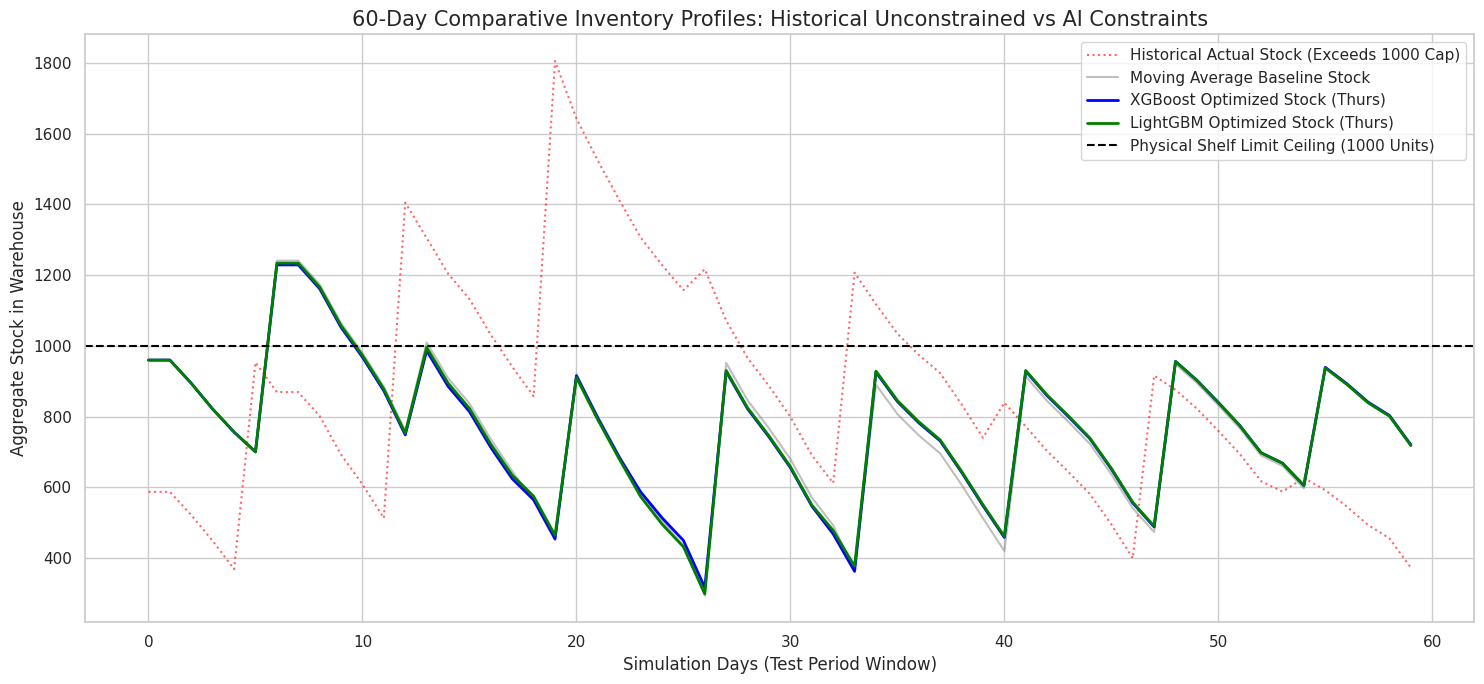

In [11]:
plt.figure(figsize=(15, 7))

# Plot historical unconstrained numbers (Using the freshly aligned variable)
plt.plot(historical_test_stock_aligned[:60], label='Historical Actual Stock (Exceeds 1000 Cap)', color='red', alpha=0.6, linestyle=':')

# Plot your baseline and ML-optimized runs
plt.plot(metrics_base['raw_stock_history'][:60], label='Moving Average Baseline Stock', color='gray', alpha=0.5)
plt.plot(metrics_xgb_thurs['raw_stock_history'][:60], label='XGBoost Optimized Stock (Thurs)', color='blue', linewidth=2)
plt.plot(metrics_lgb_thurs['raw_stock_history'][:60], label='LightGBM Optimized Stock (Thurs)', color='green', linewidth=2)

# Strict boundary ceiling line
plt.axhline(y=1000, color='black', linestyle='--', label='Physical Shelf Limit Ceiling (1000 Units)')

plt.title('60-Day Comparative Inventory Profiles: Historical Unconstrained vs AI Constraints', fontsize=15)
plt.xlabel('Simulation Days (Test Period Window)')
plt.ylabel('Aggregate Stock in Warehouse')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [12]:
# --- Scenario Matrix Grid Search ---
order_days_to_test = {'Monday':0, 'Tuesday': 1, 'Thursday': 3}
lead_times_to_test = [2, 3, 4]
ceilings_to_test = [800, 1000, 1200]

scenario_results = []

print("--- Running Multi-Dimensional Stress Test Matrix (XGBoost Engine) ---")

for day_name, day_idx in order_days_to_test.items():
    for lt in lead_times_to_test:
        for cap in ceilings_to_test:
            
            # Set target fill level slightly under physical capacity to avoid overcapacity anomalies
            target_fill = cap - 40 
            
            # Run simulation for this specific dimension combination
            res = run_max_capacity_simulation(
                actuals_dict=actual_test_values_aligned, 
                forecasts_dict=predictions_xgb_aligned, # Using our top model
                medicine_groups_arr=medicine_groups_arr, 
                historical_sod_total=historical_test_stock_aligned,
                storage_cap=cap,
                target_fill_level=target_fill,
                order_day=day_idx,
                lead_time=lt
            )
            
            # Append dimensions and results to our matrix tracker
            scenario_results.append({
                'Order Day': day_name,
                'Lead Time (Days)': lt,
                'Storage Capacity': cap,
                'Avg Daily Stock': res['avg_stock'],
                'Total Stockout Incidents': res['total_stockouts'],
                'Total Lost Sales (Units)': res['total_lost_sales'],
                'Shelf Utilization (% Days >90%)': res['pct_days_90_filled']
            })

# Convert to DataFrame for pivot analysis
df_matrix = pd.DataFrame(scenario_results)
print("Scenario Analysis Complete!")

--- Running Multi-Dimensional Stress Test Matrix (XGBoost Engine) ---
Scenario Analysis Complete!


In [13]:
print("\nMULTI-DIMENSIONAL RISK MATRIX ===")

# Adding 'Order Day' to the index splits the rows out for Tuesday vs Thursday explicitly
pivot_lead_time_expanded = df_matrix.pivot_table(
    index=['Order Day', 'Storage Capacity'], 
    columns=['Lead Time (Days)'], 
    values=['Total Lost Sales (Units)', 'Total Stockout Incidents'],
    aggfunc='mean'
)

# Format the display
display(summary_table)
display(pivot_lead_time_expanded)


MULTI-DIMENSIONAL RISK MATRIX ===


,Metric Goal,Historical Data (Unconstrained),Moving Average Baseline,SARIMA Optimization,XGBoost (Thurs Order),LightGBM Advanced (Thurs Order)
0,Avg Daily Stock (Target: Closer to 1000),666.60,718.64,721.26,717.44,717.09
1,Total Stockout Incidents (Goal: 0),0,13.00,84.00,24.00,26.00
2,Total Lost Sales Units (Goal: 0),0,290.20,638.51,411.82,431.82
3,% of Days Risking Overstock (>90% Full),15.30,7.12,6.76,7.12,7.12
4,"Days Running Lean & Safe (<10% Full, No Stockout)",Unknown,0.00,0.00,0.00,0.00
5,Days Exceeding 1000 Unit Cap (Overcapacity),27,5.00,5.00,4.00,4.00


Total Lost Sales (Units)                  \
Lead Time (Days)                                  2      3        4   
Order Day Storage Capacity                                            
Monday    800                                286.96 434.24   714.67   
          1000                                92.13 127.27   230.15   
          1200                                51.13  55.65    81.64   
Thursday  800                                501.43 727.43 1,018.47   
          1000                               233.77 411.82   523.25   
          1200                               114.77 208.29   259.91   
Tuesday   800                                277.53 456.26   844.49   
          1000                               108.27 166.64   372.60   
          1200                                30.27  57.64   179.77   

                           Total Stockout Incidents              
Lead Time (Days)                                  2     3     4  
Order Day Storage Capacity                                       
Monday    800                                 34.00 50.00 76.00  
          1000                                13.00 19.00 30.00  
          1200                                 6.00  8.00  9.00  
Thursday  800                                 39.00 53.00 87.00  
          1000                                17.00 24.00 35.00  
          1200                                11.00 12.00 18.00  
Tuesday   800                                 35.00 49.00 77.00  
          1000                                17.00 24.00 29.00  
          1200                                 4.00  8.00 15.00

In [14]:
print("\nORDER DAY EFFICIENCY ===")
pivot_days = df_matrix.pivot_table(
    index=['Order Day'], 
    columns=['Storage Capacity'], 
    values=['Total Lost Sales (Units)', 'Avg Daily Stock'],
    aggfunc='mean'
)

display(summary_table)
display(pivot_days)


ORDER DAY EFFICIENCY ===


,Metric Goal,Historical Data (Unconstrained),Moving Average Baseline,SARIMA Optimization,XGBoost (Thurs Order),LightGBM Advanced (Thurs Order)
0,Avg Daily Stock (Target: Closer to 1000),666.60,718.64,721.26,717.44,717.09
1,Total Stockout Incidents (Goal: 0),0,13.00,84.00,24.00,26.00
2,Total Lost Sales Units (Goal: 0),0,290.20,638.51,411.82,431.82
3,% of Days Risking Overstock (>90% Full),15.30,7.12,6.76,7.12,7.12
4,"Days Running Lean & Safe (<10% Full, No Stockout)",Unknown,0.00,0.00,0.00,0.00
5,Days Exceeding 1000 Unit Cap (Overcapacity),27,5.00,5.00,4.00,4.00


Avg Daily Stock               Total Lost Sales (Units)  \
Storage Capacity            800    1000   1200                     800    
Order Day                                                                 
Monday                    504.87 716.51 936.90                   478.62   
Thursday                  505.95 716.54 934.43                   749.11   
Tuesday                   501.99 713.65 933.46                   526.09   

                                
Storage Capacity   1000   1200  
Order Day                       
Monday           149.85  62.81  
Thursday         389.61 194.32  
Tuesday          215.84  89.23

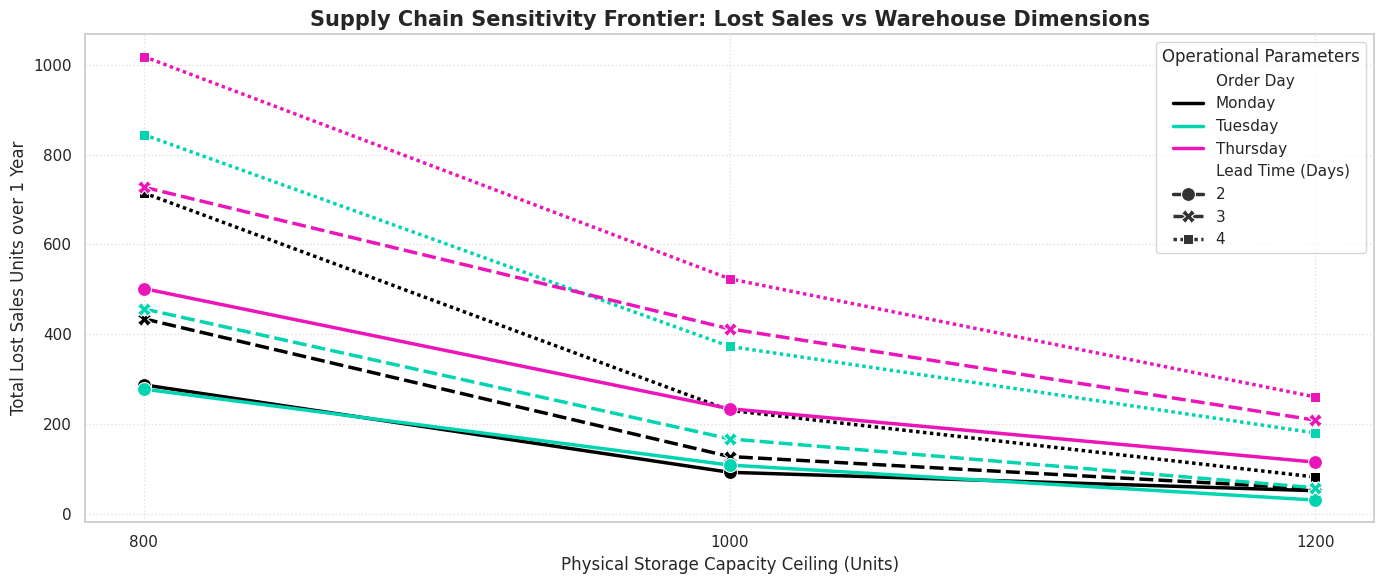

In [15]:
plt.figure(figsize=(14, 6))

# Plotting the trade-offs across capacities and lead times
sns.lineplot(
    data=df_matrix, 
    x='Storage Capacity', 
    y='Total Lost Sales (Units)', 
    hue='Order Day', 
    style='Lead Time (Days)', 
    markers=True, 
    markersize=10, 
    linewidth=2.5,
    palette=['#000000', '#00D4B1', '#EB15B9']
)

plt.title('Supply Chain Sensitivity Frontier: Lost Sales vs Warehouse Dimensions', fontsize=15, fontweight='bold')
plt.xlabel('Physical Storage Capacity Ceiling (Units)', fontsize=12)
plt.ylabel('Total Lost Sales Units over 1 Year', fontsize=12)
plt.xticks(ceilings_to_test)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Operational Parameters', loc='upper right')
plt.tight_layout()
plt.show()

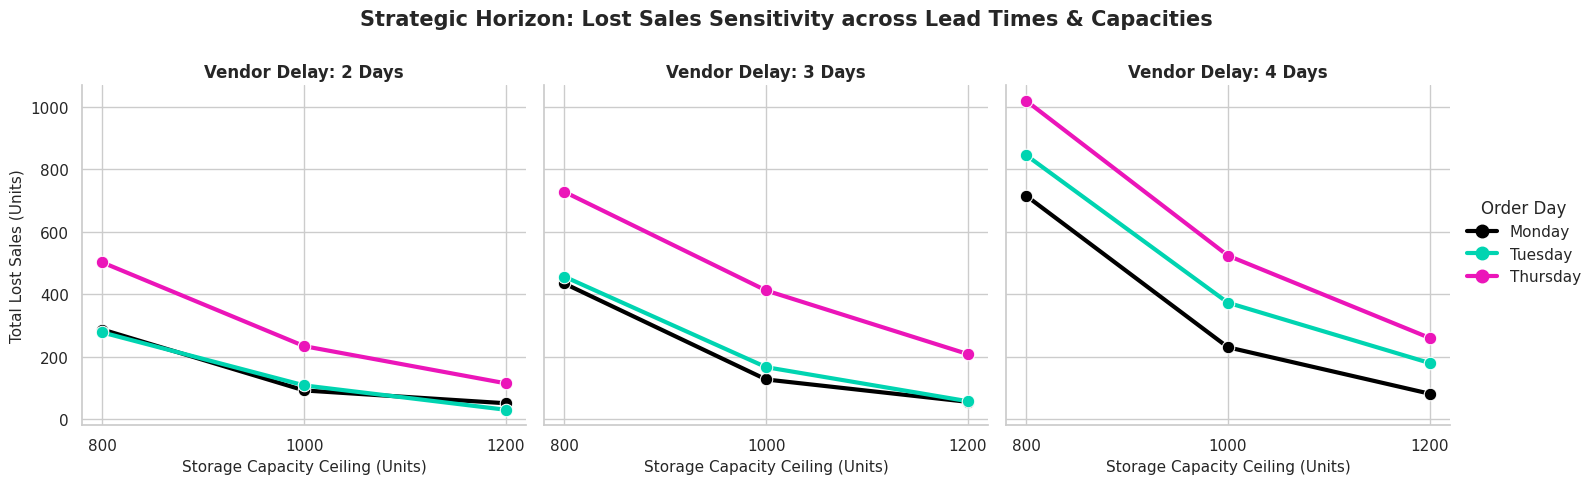

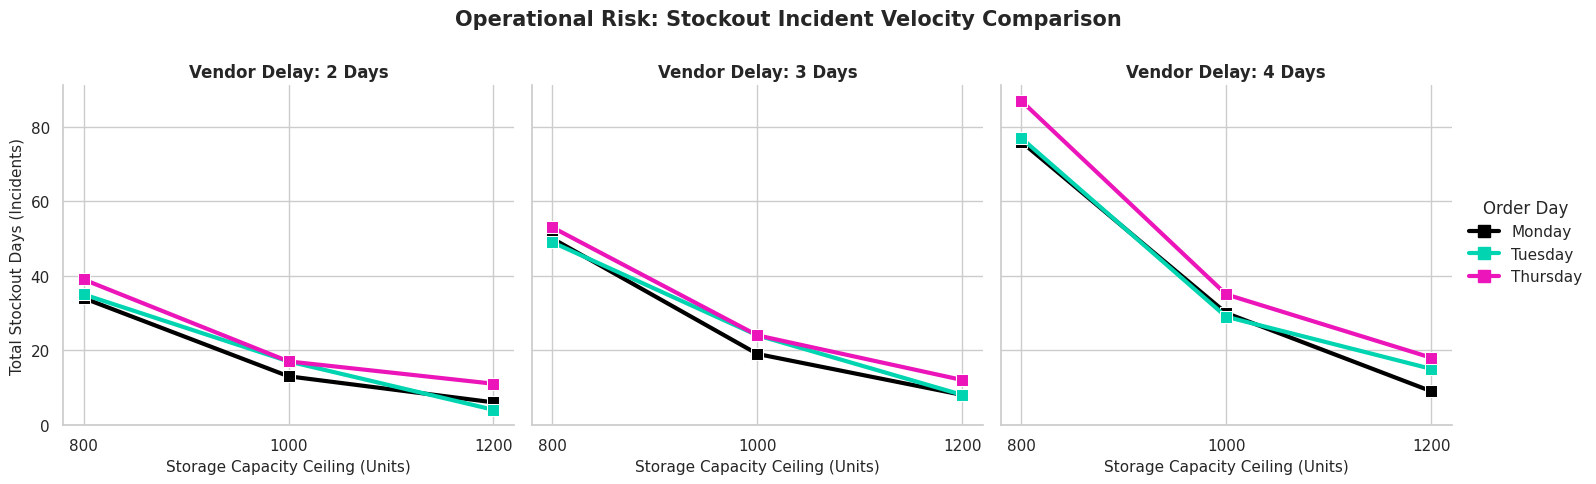

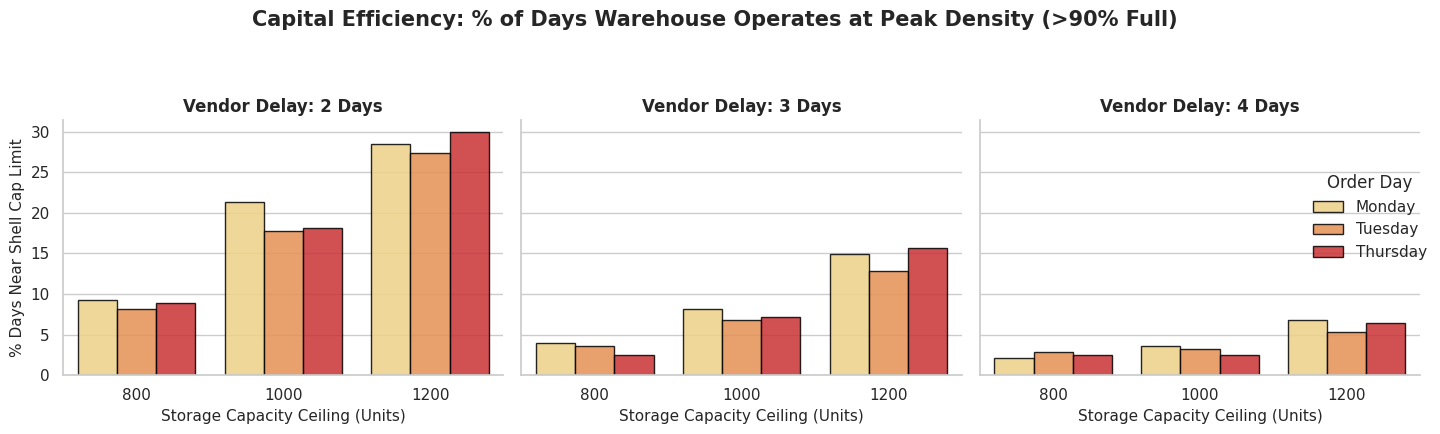

In [16]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


g1 = sns.relplot(
    data=df_matrix,
    x='Storage Capacity',
    y='Total Lost Sales (Units)',
    hue='Order Day',
    col='Lead Time (Days)',
    kind='line',
    marker='o',
    markersize=9,
    linewidth=3,
    palette=['#000000', '#00D4B1', '#EB15B9'],
    height=4.5,
    aspect=1.1
)

# Refine labels and titles to prevent truncation
g1.fig.suptitle('Strategic Horizon: Lost Sales Sensitivity across Lead Times & Capacities', 
               fontsize=15, fontweight='bold', y=1.08)
g1.set_axis_labels('Storage Capacity Ceiling (Units)', 'Total Lost Sales (Units)', fontsize=11)
g1.set(xticks=list(df_matrix['Storage Capacity'].unique()))
g1.set_titles("Vendor Delay: {col_name} Days", fontsize=12, fontweight='bold')
plt.show()


g2 = sns.relplot(
    data=df_matrix,
    x='Storage Capacity',
    y='Total Stockout Incidents',
    hue='Order Day',
    col='Lead Time (Days)',
    kind='line',
    marker='s',
    markersize=9,
    linewidth=3,
    palette=['#000000', '#00D4B1', '#EB15B9'],
    height=4.5,
    aspect=1.1
)

g2.fig.suptitle('Operational Risk: Stockout Incident Velocity Comparison', 
               fontsize=15, fontweight='bold', y=1.08)
g2.set_axis_labels('Storage Capacity Ceiling (Units)', 'Total Stockout Days (Incidents)', fontsize=11)
g2.set(xticks=list(df_matrix['Storage Capacity'].unique()))
g2.set_titles("Vendor Delay: {col_name} Days", fontsize=12, fontweight='bold')
plt.show()


g3 = sns.catplot(
    data=df_matrix,
    x='Storage Capacity',
    y='Shelf Utilization (% Days >90%)',
    hue='Order Day',
    col='Lead Time (Days)',
    kind='bar',
    palette='YlOrRd',
    edgecolor='black',
    alpha=0.85,
    height=4,
    aspect=1.1
)

g3.fig.suptitle('Capital Efficiency: % of Days Warehouse Operates at Peak Density (>90% Full)', 
               fontsize=15, fontweight='bold', y=1.08)
g3.set_axis_labels('Storage Capacity Ceiling (Units)', '% Days Near Shell Cap Limit', fontsize=11)
g3.set_titles("Vendor Delay: {col_name} Days", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

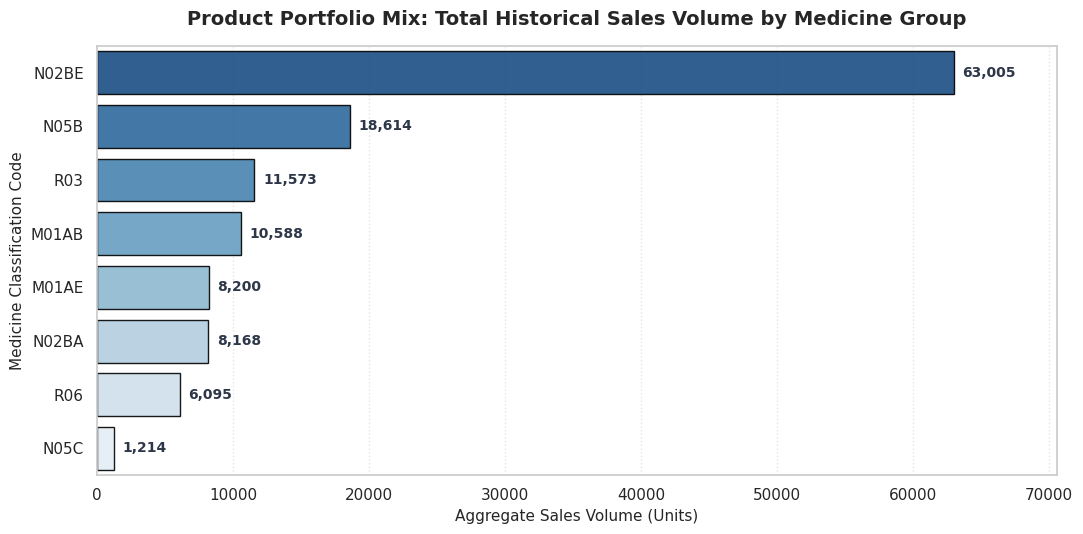

In [17]:

total_volumes = df[medicine_groups_arr].sum().sort_values(ascending=False).reset_index()
total_volumes.columns = ['Medicine Group', 'Total Units Sold']

plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=total_volumes,
    y='Medicine Group',
    x='Total Units Sold',
    palette='Blues_r',
    edgecolor='black',
    alpha=0.9
)


for index, row in total_volumes.iterrows():
    plt.text(
        row['Total Units Sold'] + (total_volumes['Total Units Sold'].max() * 0.01), 
        index, 
        f"{row['Total Units Sold']:,.0f}", 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color='#2d3748'
    )

plt.title('Product Portfolio Mix: Total Historical Sales Volume by Medicine Group', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aggregate Sales Volume (Units)', fontsize=11)
plt.ylabel('Medicine Classification Code', fontsize=11)
plt.xlim(0, total_volumes['Total Units Sold'].max() * 1.12) # Clear buffer for annotations
plt.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

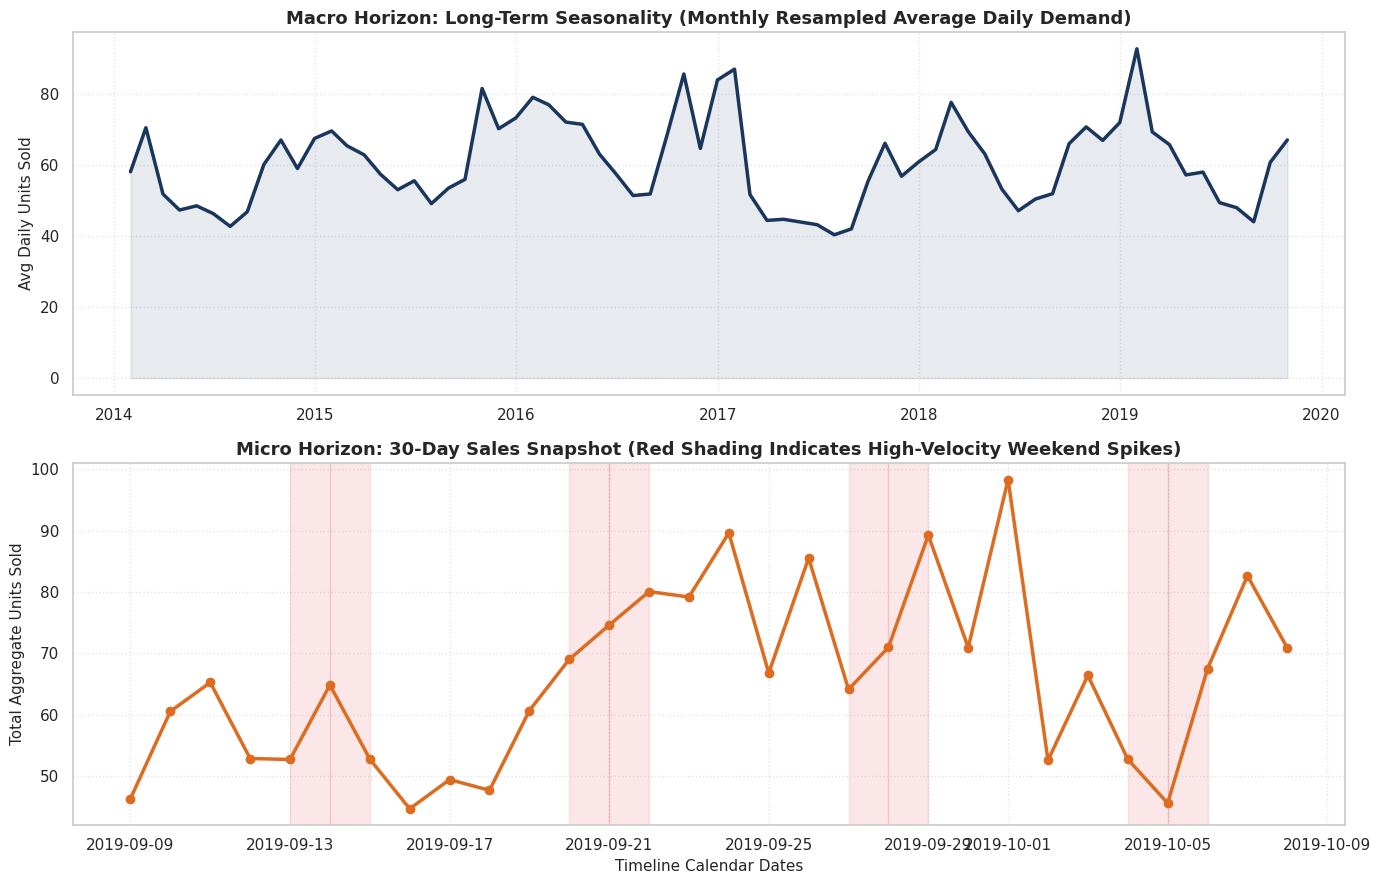

In [18]:
# Ensure your index is set to datetime
if not isinstance(df.index, plt.matplotlib.dates.datetime.datetime):
    df.index = pd.to_datetime(df.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

df_monthly = df[medicine_groups_arr].sum(axis=1).resample('M').mean()
ax1.plot(df_monthly.index, df_monthly.values, color='#1a365d', linewidth=2.5, label='Monthly Average Demand')
ax1.fill_between(df_monthly.index, df_monthly.values, color='#1a365d', alpha=0.1)
ax1.set_title('Macro Horizon: Long-Term Seasonality (Monthly Resampled Average Daily Demand)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Avg Daily Units Sold', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.5)

sample_window = df[medicine_groups_arr].sum(axis=1).iloc[-30:]
ax2.plot(sample_window.index, sample_window.values, color='#dd6b20', linewidth=2.5, marker='o', zorder=3)

for date in sample_window.index:
    if date.dayofweek in [4, 5]: # Friday and Saturday
        ax2.axvspan(date, date + pd.Timedelta(days=1), color='#e53e3e', alpha=0.12, zorder=1)

ax2.set_title('Micro Horizon: 30-Day Sales Snapshot (Red Shading Indicates High-Velocity Weekend Spikes)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Timeline Calendar Dates', fontsize=11)
ax2.set_ylabel('Total Aggregate Units Sold', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

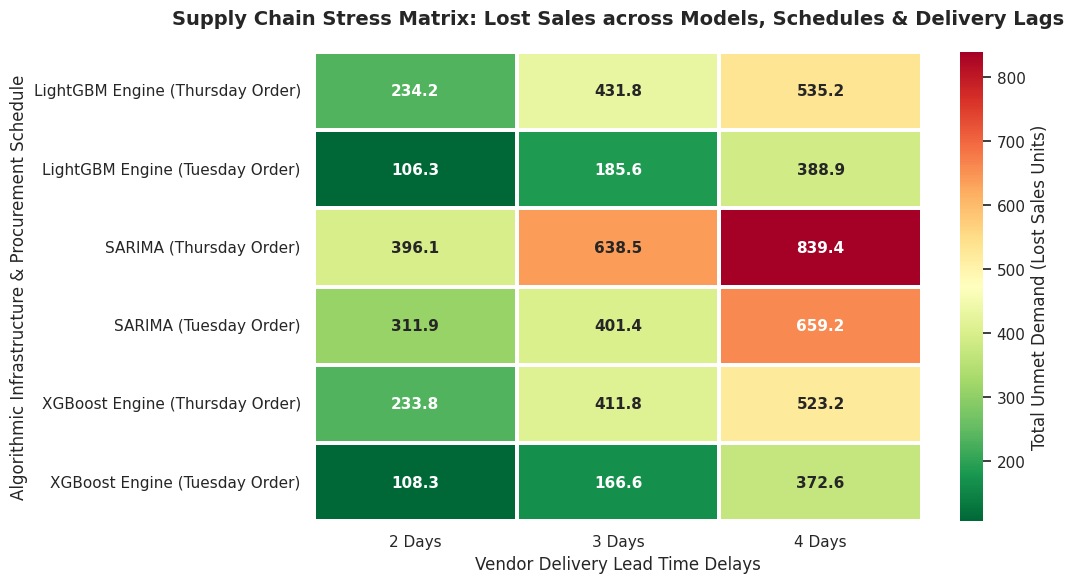

In [19]:

models_to_test = {
    'SARIMA': predictions_sarima_aligned,
    'XGBoost Engine': predictions_xgb_aligned,
    'LightGBM Engine': predictions_lgb_aligned
}
order_days_to_test = {'Tuesday Order': 1, 'Thursday Order': 3}
lead_times_to_test = [2, 3, 4]
fixed_capacity = 1000

expanded_scenario_results = []

for model_name, forecast_dict in models_to_test.items():
    for day_name, day_idx in order_days_to_test.items():
        for lt in lead_times_to_test:
            # Re-run simulation parameters
            target_fill = fixed_capacity - 40
            res = run_max_capacity_simulation(
                actuals_dict=actual_test_values_aligned, 
                forecasts_dict=forecast_dict, 
                medicine_groups_arr=medicine_groups_arr, 
                historical_sod_total=historical_test_stock_aligned,
                storage_cap=fixed_capacity,
                target_fill_level=target_fill,
                order_day=day_idx,
                lead_time=lt
            )
            
            expanded_scenario_results.append({
                'System Configuration': f"{model_name} ({day_name})",
                'Vendor Lead Time (Days)': f"{lt} Days",
                'Lost Sales (Units)': res['total_lost_sales']
            })

            
df_heat = pd.DataFrame(expanded_scenario_results)
pivot_heat = df_heat.pivot_table(
    index='System Configuration', 
    columns='Vendor Lead Time (Days)', 
    values='Lost Sales (Units)'
)

# Re-order index columns
pivot_heat = pivot_heat[['2 Days', '3 Days', '4 Days']]

plt.figure(figsize=(11, 6))
sns.heatmap(
    pivot_heat, 
    annot=True, 
    fmt=",.1f", 
    cmap='RdYlGn_r', 
    linewidths=1.5, 
    linecolor='white',
    cbar_kws={'label': 'Total Unmet Demand (Lost Sales Units)'},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Supply Chain Stress Matrix: Lost Sales across Models, Schedules & Delivery Lags', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Algorithmic Infrastructure & Procurement Schedule', fontsize=12)
plt.xlabel('Vendor Delivery Lead Time Delays', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()